# Density Plot (KDE)

Runnable example from the accompanying README. Run the code cell below to generate the chart.


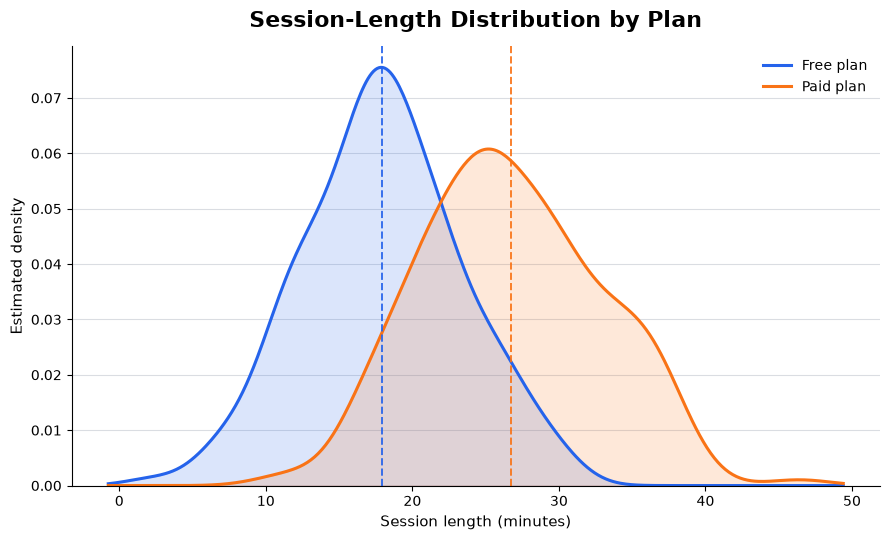

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# 1. Create reproducible sample session lengths, measured in minutes.
rng = np.random.default_rng(seed=8)
free_sessions = rng.normal(loc=18, scale=5, size=180)
paid_sessions = rng.normal(loc=27, scale=6, size=180)

# 2. Build one shared x-axis range so the distributions are comparable.
all_sessions = np.concatenate([free_sessions, paid_sessions])
x_values = np.linspace(all_sessions.min() - 3, all_sessions.max() + 3, 400)

# 3. Estimate a smooth density for each group.
#    `bw_method` controls smoothing: a smaller value gives a more detailed curve,
#    while a larger value creates a smoother curve.
free_kde = gaussian_kde(free_sessions, bw_method=0.35)
paid_kde = gaussian_kde(paid_sessions, bw_method=0.35)
free_density = free_kde(x_values)
paid_density = paid_kde(x_values)

# 4. Create a figure and axes for the chart.
fig, ax = plt.subplots(figsize=(9, 5.5))

# 5. Draw and lightly fill each density curve.
ax.plot(x_values, free_density, color="#2563EB", linewidth=2.2, label="Free plan")
ax.fill_between(x_values, free_density, color="#2563EB", alpha=0.16)

ax.plot(x_values, paid_density, color="#F97316", linewidth=2.2, label="Paid plan")
ax.fill_between(x_values, paid_density, color="#F97316", alpha=0.16)

# 6. Mark each group's mean to help readers compare typical values.
for sessions, color in [(free_sessions, "#2563EB"), (paid_sessions, "#F97316")]:
    ax.axvline(sessions.mean(), color=color, linestyle="--", linewidth=1.4, alpha=0.9)

# 7. Add a title, labels, and a legend.
ax.set_title(
    "Session-Length Distribution by Plan", fontsize=16, fontweight="bold", pad=14
)
ax.set_xlabel("Session length (minutes)", fontsize=11)
ax.set_ylabel("Estimated density", fontsize=11)
ax.legend(frameon=False)

# 8. Add a light horizontal grid. Density is an estimate, so start at zero.
ax.set_ylim(bottom=0)
ax.grid(axis="y", color="#D1D5DB", linewidth=0.8, alpha=0.8)
ax.set_axisbelow(True)

# 9. Remove unnecessary borders, save a high-resolution image, and display it.
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("density_plot_kde.png", dpi=200, bbox_inches="tight")
plt.show()